In [12]:
# get the data ready 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
heart_disease = pd.read_csv("data/13.1 heart-disease.csv")
heart_disease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [3]:
import warnings
warnings.filterwarnings("default")

# introduction to skleran 
this notbook demonstrate some the best funcytions inthe sk learn 


what we cover : 
1. An end-to-end sk workflow
2. getting the data ready
3.  choose the right estimator or algorithm
4.  fit the model /algorithms and use it to make the predications
5.  evaluating
6.  improve
7.  save and load
8.  and put all together


## 1.end-t0-end scikit-learn workflow

In [46]:
# craete X (feature matrix)
x = heart_disease.drop("target", axis = 1)

# create the y (whic is the labels)
y = heart_disease["target"]

In [47]:
# choose the write model and hyperparameter
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()

# keep the deafult  hyperprameters
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [48]:
# . fit  the model to the  traing the data
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2)


In [51]:
clf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [53]:
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
46,44,1,2,140,235,0,0,180,0,0.0,2,0,2
209,59,1,0,140,177,0,1,162,1,0.0,2,1,3
77,59,1,1,140,221,0,1,164,1,0.0,2,0,2
72,29,1,1,130,204,0,0,202,0,0.0,2,0,2
84,42,0,0,102,265,0,0,122,0,0.6,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,51,0,0,130,305,0,1,142,1,1.2,1,0,3
259,38,1,3,120,231,0,1,182,1,3.8,1,0,3
105,68,0,2,120,211,0,0,115,0,1.5,1,0,2
53,44,0,2,108,141,0,1,175,0,0.6,1,0,2


In [23]:

y_label = clf.predict(np.array([0,1,2,3,4]))

C:\Users\Ashavdeep\Desktop\sample_project_1\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


ValueError: Expected 2D array, got 1D array instead:
array=[0. 1. 2. 3. 4.].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [28]:
y_preds =  clf.predict(x_test)
y_preds

array([0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1])

In [25]:
y_test 

211    0
156    1
285    0
283    0
152    1
      ..
181    0
41     1
76     1
229    0
71     1
Name: target, Length: 61, dtype: int64

In [26]:
 # Evalute the model on traing data and test data 
    clf.score(x_train, y_train)

1.0

In [27]:
clf.score(x_test, y_test)

0.8524590163934426

In [30]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.91      0.74      0.82        27
           1       0.82      0.94      0.88        34

    accuracy                           0.85        61
   macro avg       0.86      0.84      0.85        61
weighted avg       0.86      0.85      0.85        61



In [32]:
confusion_matrix(y_test,y_preds)

array([[20,  7],
       [ 2, 32]])

In [33]:
accuracy_score(y_test, y_preds)

0.8524590163934426

In [40]:
# imporve the model 
# try different types of the  n_estimators
np.random.seed(42)
for i in range(10, 100, 10):
    print(f"Trying model with {i} estimators..")
clf= RandomForestClassifier(n_estimators=i).fit(x_train,y_train)
print(f"Model accuracy on test set: {clf.score(x_test,y_test) * 100:.2f}%")
print("")


Trying model with 10 estimators..
Trying model with 20 estimators..
Trying model with 30 estimators..
Trying model with 40 estimators..
Trying model with 50 estimators..
Trying model with 60 estimators..
Trying model with 70 estimators..
Trying model with 80 estimators..
Trying model with 90 estimators..
Model accuracy on test set: 85.25%



In [44]:
# saving the model  

import pickle
pickle.dump(clf,open("random_forst_model_1.pkl", "wb"))

In [45]:
loaded_model= pickle.load(open("random_forst_model_1.pkl","rb"))
loaded_model.score(x_test, y_test)

0.8524590163934426

## 1 getting the dat ready to be used with machine learning 
three main things we have to do:
1 split the data into the features and labels (usually `X` and `y`)
2 filling(also called imputting ) or disgreading misssing values 
3. converting the non-numeric values into the numeric values also callled the feature encoding 

In [61]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [62]:
x =  heart_disease.drop("target", axis=1)
x.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [63]:
y = heart_disease["target"]
y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [64]:
# split the data into the traing sets and test sets 
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2)


In [65]:
x_train.shape, x_test.shape,y_test.shape,y_train.shape

((242, 13), (61, 13), (61,), (242,))

In [66]:
x.shape

(303, 13)

In [67]:
len(heart_disease)

303

In [8]:
import pandas as pd

## Make sure the data  in numeric values

In [14]:
car_sales = pd.read_csv("cardata.csv")
car_sales.head()


,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,"$4,000"
1,Honda,Red,87899.0,4.0,"$5,000"
2,Toyota,Blue,NaN,3.0,"$7,000"
3,BMW,Black,11179.0,5.0,"$22,000"
4,Nissan,White,213095.0,4.0,"$3,500"


In [15]:
len(car_sales)

10

In [1]:
car_sales.datatypes


NameError: name 'car_sales' is not defined

In [2]:
car_sales

NameError: name 'car_sales' is not defined

In [3]:
car_sales.head()


NameError: name 'car_sales' is not defined

In [4]:
car_sales = pd.read_csv("cardata.csv")
car_sales.head()


NameError: name 'pd' is not defined

In [6]:
car_sales.head()

NameError: name 'car_sales' is not defined

In [7]:
car_sales = pd.read_csv("cardata.csv")
car_sales.head()


,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,"$4,000"
1,Honda,Red,87899.0,4.0,"$5,000"
2,Toyota,Blue,NaN,3.0,"$7,000"
3,BMW,Black,11179.0,5.0,"$22,000"
4,Nissan,White,213095.0,4.0,"$3,500"


In [8]:
car_sales.dtypes

Make         object
Colour       object
Odometer    float64
Doors       float64
Price        object
dtype: object

In [9]:
# 1. Remove the $, commas, and the extra dot if present
# 2. Convert to float first (to handle decimals), then to int
car_sales["Price"] = car_sales["Price"].str.replace(r'[\$,]', '', regex=True).astype(float).astype(int)

# Check the result
car_sales["Price"].dtype

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [11]:
# 1. Clean the string and convert to float
car_sales["Price"] = car_sales["Price"].str.replace(r'[\$,]', '', regex=True).astype(float)

# 2. Fill NaN values with 0 (or use .mean())
car_sales["Price"] = car_sales["Price"].fillna(0)

# 3. Now convert to int
car_sales["Price"] = car_sales["Price"].astype(int)

AttributeError: Can only use .str accessor with string values!

In [12]:
car_sales = pd.read_csv("cardata.csv")

In [15]:
# Clean strings, fill missing values with 0, and convert to int
car_sales["Price"] = car_sales["Price"].str.replace(r'[\$,]', '', regex=True).astype(float).fillna(0).astype(int)

# Verify the change
car_sales.head()

AttributeError: Can only use .str accessor with string values!

In [16]:
car_sales = pd.read_csv("cardata.csv")

In [17]:
# Clean strings, fill missing values with 0, and convert to int
car_sales["Price"] = car_sales["Price"].str.replace(r'[\$,]', '', regex=True).astype(float).fillna(0).astype(int)

# Verify the change
car_sales.head()

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,4000
1,Honda,Red,87899.0,4.0,5000
2,Toyota,Blue,NaN,3.0,7000
3,BMW,Black,11179.0,5.0,22000
4,Nissan,White,213095.0,4.0,3500


In [18]:
# 1. Calculate the mean of the Odometer column
odometer_mean = car_sales["Odometer"].mean()

# 2. Fill the missing values with that mean
car_sales["Odometer"] = car_sales["Odometer"].fillna(odometer_mean)

# Check the data again to see row 2
car_sales.head()

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.000000,4.0,4000
1,Honda,Red,87899.000000,4.0,5000
2,Toyota,Blue,92302.666667,3.0,7000
3,BMW,Black,11179.000000,5.0,22000
4,Nissan,White,213095.000000,4.0,3500


In [19]:
car_sales.dtypes

Make         object
Colour       object
Odometer    float64
Doors       float64
Price         int64
dtype: object

## know we get the correct data 
 1 Know we will start the process of converting the words into the number

In [23]:
# split into x/y
x = car_sales.drop("Price", axis=1)
y = car_sales["Price"]

# split into the training and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [24]:
# build machine learing model
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(x_train,y_train)
model.score(x_test,y_test)

ValueError: could not convert string to float: 'Honda'

In [30]:
# Trun the categoires into the numbers 

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour", "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",
                                  one_hot,
                                  categorical_features
                                 )],
                               remainder="passthrough")
transformed_X = transformer.fit_transform(x)
transformed_X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 40 stored elements and shape (10, 16)>

In [31]:
pd.DataFrame(transformed_X)

,0
0,<Compressed Sparse Row sparse matrix of dtype ...
1,<Compressed Sparse Row sparse matrix of dtype ...
2,<Compressed Sparse Row sparse matrix of dtype ...
3,<Compressed Sparse Row sparse matrix of dtype ...
4,<Compressed Sparse Row sparse matrix of dtype ...
5,<Compressed Sparse Row sparse matrix of dtype ...
6,<Compressed Sparse Row sparse matrix of dtype ...
7,<Compressed Sparse Row sparse matrix of dtype ...
8,<Compressed Sparse Row sparse matrix of dtype ...
9,<Compressed Sparse Row sparse matrix of dtype ...


In [34]:
# Convert the sparse matrix to a dense array so we can see the numbers
transformed_X = pd.DataFrame(transformed_X.toarray())
transformed_X

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,150043.000000
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,87899.000000
2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,92302.666667
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,11179.000000
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,213095.000000
5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,92302.666667
6,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,92302.666667
7,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,92302.666667
8,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,60000.000000
9,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,31600.000000


In [36]:
dummies = pd.get_dummies(car_sales[["Make","Colour","Doors"]])
dummies

,Doors,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota,Colour_Black,Colour_Blue,Colour_Green,Colour_Red,Colour_White
0,4.0,False,False,False,True,False,False,False,False,True
1,4.0,False,True,False,False,False,False,False,True,False
2,3.0,False,False,False,True,False,True,False,False,False
3,5.0,True,False,False,False,True,False,False,False,False
4,4.0,False,False,True,False,False,False,False,False,True
5,4.0,False,False,False,True,False,False,True,False,False
6,4.0,False,True,False,False,False,False,False,False,False
7,4.0,False,True,False,False,False,True,False,False,False
8,NaN,False,False,False,True,False,False,False,False,True
9,4.0,False,False,False,False,False,False,False,False,True


In [38]:
# let,s refit the model
np.random.seed(42)
x_train, x_test, y_train,y_test = train_test_split(transformed_X,
                                                   y,
                                                  test_size=0.2)
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [39]:
model.score(x_train,y_train)

0.8571917519088301

### what if their is some missing values 
1 filll with some values(also kown as  imputation).
2 Remove the sample with missing data altogether


In [40]:
car_sales

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.000000,4.0,4000
1,Honda,Red,87899.000000,4.0,5000
2,Toyota,Blue,92302.666667,3.0,7000
3,BMW,Black,11179.000000,5.0,22000
4,Nissan,White,213095.000000,4.0,3500
5,Toyota,Green,92302.666667,4.0,4500
6,Honda,NaN,92302.666667,4.0,7500
7,Honda,Blue,92302.666667,4.0,0
8,Toyota,White,60000.000000,NaN,0
9,NaN,White,31600.000000,4.0,9700


In [41]:
car_sales.isna().sum()

Make        1
Colour      1
Odometer    0
Doors       1
Price       0
dtype: int64

In [ ]:
 # creat the x and y 
x= car_sales.drop("Price", axis = 1)
y = car_sales["Price"]

In [43]:
# Trun the categoires into the numbers 

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour", "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",
                                  one_hot,
                                  categorical_features
                                 )],
                               remainder="passthrough")
transformed_X = transformer.fit_transform(x)
transformed_X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 40 stored elements and shape (10, 16)>

In [43]:
# Trun the categoires into the numbers 

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour", "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",
                                  one_hot,
                                  categorical_features
                                 )],
                               remainder="passthrough")
transformed_X = transformer.fit_transform(x)
transformed_X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 40 stored elements and shape (10, 16)>

In [44]:
car_missing_data = pd.read_csv("data/9.1 car-sales-missing-data - 9.1 car-sales-missing-data.csv.csv")

In [45]:
car_missing_data

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,"$4,000"
1,Honda,Red,87899.0,4.0,"$5,000"
2,Toyota,Blue,NaN,3.0,"$7,000"
3,BMW,Black,11179.0,5.0,"$22,000"
4,Nissan,White,213095.0,4.0,"$3,500"
5,Toyota,Green,NaN,4.0,"$4,500"
6,Honda,NaN,NaN,4.0,"$7,500"
7,Honda,Blue,NaN,4.0,NaN
8,Toyota,White,60000.0,NaN,NaN
9,NaN,White,31600.0,4.0,"$9,700"


In [46]:
car_missing_data["Price"] = car_missing_data["Price"].str.replace(r'[\$,]', '', regex=True).astype(float)

In [47]:
car_missing_data

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,4000.0
1,Honda,Red,87899.0,4.0,5000.0
2,Toyota,Blue,NaN,3.0,7000.0
3,BMW,Black,11179.0,5.0,22000.0
4,Nissan,White,213095.0,4.0,3500.0
5,Toyota,Green,NaN,4.0,4500.0
6,Honda,NaN,NaN,4.0,7500.0
7,Honda,Blue,NaN,4.0,NaN
8,Toyota,White,60000.0,NaN,NaN
9,NaN,White,31600.0,4.0,9700.0


In [50]:
# creating the x and y 
x = car_missing_data.drop("Price", axis= 1)
y = car_missing_data["Price"]


In [51]:
# Trun the categoires into the numbers 

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour", "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",
                                  one_hot,
                                  categorical_features
                                 )],
                               remainder="passthrough")
transformed_X = transformer.fit_transform(x)
transformed_X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 40 stored elements and shape (10, 16)>

### option 1 : fill miss data with pandas
`

In [54]:
# fill the Make column
car_missing_data["Make"].fillna("missing", inplace=True)

# fill the Colour column
car_missing_data["Colour"].fillna("missing", inplace=True)

# fill the Odometer column with the mean
car_missing_data["Odometer"].fillna(car_missing_data["Odometer"].mean(), inplace=True)

# fill the Doors column
car_missing_data["Doors"].fillna(4, inplace=True)

C:\Users\Ashavdeep\AppData\Local\Temp\ipykernel_11692\1555462802.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car_missing_data["Make"].fillna("missing", inplace=True)
C:\Users\Ashavdeep\AppData\Local\Temp\ipykernel_11692\1555462802.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [55]:
# 1. Fill the Make column
car_missing_data["Make"] = car_missing_data["Make"].fillna("missing")

# 2. Fill the Colour column
car_missing_data["Colour"] = car_missing_data["Colour"].fillna("missing")

# 3. Fill the Odometer column with the mean
car_missing_data["Odometer"] = car_missing_data["Odometer"].fillna(car_missing_data["Odometer"].mean())

# 4. Fill the Doors column
car_missing_data["Doors"] = car_missing_data["Doors"].fillna(4)

In [56]:
car_missing_data

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.000000,4.0,4000.0
1,Honda,Red,87899.000000,4.0,5000.0
2,Toyota,Blue,92302.666667,3.0,7000.0
3,BMW,Black,11179.000000,5.0,22000.0
4,Nissan,White,213095.000000,4.0,3500.0
5,Toyota,Green,92302.666667,4.0,4500.0
6,Honda,missing,92302.666667,4.0,7500.0
7,Honda,Blue,92302.666667,4.0,NaN
8,Toyota,White,60000.000000,4.0,NaN
9,missing,White,31600.000000,4.0,9700.0


In [57]:
car_missing_data.isna().sum()

Make        0
Colour      0
Odometer    0
Doors       0
Price       2
dtype: int64

In [60]:
# REMOVE THE RAWS WITH NISSING  price values 
car_missing_data = car_missing_data.dropna()

In [61]:
car_missing_data.isna().sum()

Make        0
Colour      0
Odometer    0
Doors       0
Price       0
dtype: int64

In [63]:
len(car_missing_data)

8

In [64]:
x = car_missing_data.drop("Price", axis = 1)
y = car_missing_data["Price"]

In [66]:
# Trun the categoires into the numbers 

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour", "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",
                                  one_hot,
                                  categorical_features
                                 )],
                               remainder="passthrough")
transformed_X = transformer.fit_transform(car_missing_data)
transformed_X

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 0.00000000e+00, 1.50043000e+05, 4.00000000e+03],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 0.00000000e+00, 8.78990000e+04, 5.00000000e+03],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 9.23026667e+04, 7.00000000e+03],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.000

### option 2 : Filling values with sacikit-learn


In [12]:
car_missing_missing = pd.read_csv("data/9.1 car-sales-missing-data - 9.1 car-sales-missing-data.csv.csv")
car_missing_missing

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,"$4,000"
1,Honda,Red,87899.0,4.0,"$5,000"
2,Toyota,Blue,NaN,3.0,"$7,000"
3,BMW,Black,11179.0,5.0,"$22,000"
4,Nissan,White,213095.0,4.0,"$3,500"
5,Toyota,Green,NaN,4.0,"$4,500"
6,Honda,NaN,NaN,4.0,"$7,500"
7,Honda,Blue,NaN,4.0,NaN
8,Toyota,White,60000.0,NaN,NaN
9,NaN,White,31600.0,4.0,"$9,700"


In [13]:
car_missing_missing["Price"] = car_missing_missing["Price"].str.replace(r'[\$,]', '', regex=True)

In [14]:
car_missing_missing

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,4000
1,Honda,Red,87899.0,4.0,5000
2,Toyota,Blue,NaN,3.0,7000
3,BMW,Black,11179.0,5.0,22000
4,Nissan,White,213095.0,4.0,3500
5,Toyota,Green,NaN,4.0,4500
6,Honda,NaN,NaN,4.0,7500
7,Honda,Blue,NaN,4.0,NaN
8,Toyota,White,60000.0,NaN,NaN
9,NaN,White,31600.0,4.0,9700


In [15]:
# drpping the raws with no values in price colun
car_missing_missing.dropna(subset = ["Price"])

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,4000
1,Honda,Red,87899.0,4.0,5000
2,Toyota,Blue,NaN,3.0,7000
3,BMW,Black,11179.0,5.0,22000
4,Nissan,White,213095.0,4.0,3500
5,Toyota,Green,NaN,4.0,4500
6,Honda,NaN,NaN,4.0,7500
9,NaN,White,31600.0,4.0,9700


In [16]:
# split x and y 
x = car_missing_missing.drop("Price", axis=1)
y = car_missing_missing["Price"]

In [20]:
# fill misssing value with slk learn
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

#c fill categorical values with missing and numeric vales with mean 
car_imputer = SimpleImputer(strategy="constant", fill_value="missing")
door_imputer = SimpleImputer(strategy= "constant", fill_value = 4)
num_imputer = SimpleImputer(strategy = "mean")

# define columns
caR_features = ["Make","Colour"]
door_feature = ["Doors"]
num_feature = ["Odometer"]

# create an imputer(something that fills missing data)
# Create the transformer with THREE items per tuple
imputer = ColumnTransformer([
    ("cat_imputer", car_imputer, caR_features),
    ("door_imputer", door_imputer, door_feature), # Make sure 'door_imputer' is here!
    ("num_imputer", num_imputer, num_feature)     # Make sure 'num_imputer' is here!
])

# Now transform (ensure you use the correct variable name for your data, e.g., x)
filled_x = imputer.fit_transform(x)
filled_x

array([['Toyota', 'White', 4.0, 150043.0],
       ['Honda', 'Red', 4.0, 87899.0],
       ['Toyota', 'Blue', 3.0, 92302.66666666667],
       ['BMW', 'Black', 5.0, 11179.0],
       ['Nissan', 'White', 4.0, 213095.0],
       ['Toyota', 'Green', 4.0, 92302.66666666667],
       ['Honda', 'missing', 4.0, 92302.66666666667],
       ['Honda', 'Blue', 4.0, 92302.66666666667],
       ['Toyota', 'White', 4.0, 60000.0],
       ['missing', 'White', 4.0, 31600.0]], dtype=object)

In [21]:
car_sales_filled = pd.DataFrame(filled_x,columns=["Make","Colour","Doors","Odometer"])
car_sales_filled.head()

,Make,Colour,Doors,Odometer
0,Toyota,White,4.0,150043.0
1,Honda,Red,4.0,87899.0
2,Toyota,Blue,3.0,92302.666667
3,BMW,Black,5.0,11179.0
4,Nissan,White,4.0,213095.0


In [22]:
car_sales_filled.isna().sum()

Make        0
Colour      0
Doors       0
Odometer    0
dtype: int64

In [23]:
# Trun the categoires into the numbers 

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour", "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",
                                  one_hot,
                                  categorical_features
                                 )],
                               remainder="passthrough")
transformed_X = transformer.fit_transform(car_sales_filled)
transformed_X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 40 stored elements and shape (10, 15)>

In [7]:
# Now we got the data with no unfilled value and data is in numeric
# lets fit a model
np.random.seed(42)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
X_train,X_test, Y_train, Y_test = train_test_split(transformed_X,
                                                  y,
                                                   test_size= 0.2
                                                  )
model = RandomForestRegressor()
model.fit(X_train, Y_train)
model.score(X_test,Y_test)

NameError: name 'transformed_X' is not defined

In [27]:
# This removes the rows from the original dataframe where Price is missing
car_missing_missing.dropna(subset=["Price"], inplace=True)


In [29]:
# Now X and y will have 8 rows instead of 10
X = car_missing_missing.drop("Price", axis=1)
y = car_missing_missing["Price"]

In [30]:
# Fill missing values in X
filled_X = imputer.fit_transform(X)

# Convert to numeric
transformed_X = transformer.fit_transform(pd.DataFrame(filled_X, columns=["Make", "Colour", "Doors", "Odometer"]))

In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(transformed_X, y, test_size=0.2)
model.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [5]:
 Now we got the data with no unfilled value and data is in numeric
# lets fit a model
np.random.seed(42)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
X_train,X_test, Y_train, Y_test = train_test_split(transformed_X,
                                                  y,
                                                   test_size= 0.2
                                                  )
model = RandomForestRegressor()
model.fit(X_train, Y_train)
model.score(X_test,Y_test)

IndentationError: unexpected indent (1765200658.py, line 1)

In [11]:
# Now we got the data with no unfilled value and data is in numeric
# lets fit a model
np.random.seed(42)

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Ensure transformed_X and y have the same number of rows (8)
X_train, X_test, Y_train, Y_test = train_test_split(transformed_X, 
                                                    y, 
                                                    test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, Y_train)
model.score(X_test, Y_test)

NameError: name 'transformed_X' is not defined

## 2: CHOOSING THE right estimator/algorithm for our problems
  sacikit-Leran uses estimator as another term for machin learning models and algorithms 
   * classification- predicating whether a sample is one thing or another 
  * Regression -predicating number

   setp 1 - check the sklearn machine learing map..  https://scikit-learn.org/stable/machine_learning_map.html

### 2.1 picking the machin lering model for the  regression models


In [57]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing = fetch_california_housing()
housing


{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [58]:
housing_df = pd.DataFrame(housing["data"], columns= housing["feature_names"])
housing_df["target"] = pd.Series(housing["target"])
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
len(housing_df)

20640

In [59]:
# lets try the ridge regression model
from sklearn.linear_model import Ridge

#seetup the random seeds
np.random.seed(42)

# create the data
X = housing_df.drop("target",axis=1)
Y = housing_df["target"]

# split in to train and test 
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size= 0.2)

# Instantiate the Ridge model

model= Ridge()
model.fit(x_train,y_train)

#check the socre on ridge nodel
model.score(x_test,y_test)

0.5758549611440131

In [60]:
# let's try the Random forest Regressor
from sklearn.ensemble import RandomForestRegressor

# setup the random seed
np.random.seed(42)

# create the data
x = housing_df.drop("target", axis=1)
y = housing_df["target"]
# split the data 

x_train,x_test, y_train,y_test = train_test_split(x,y, test_size= 0.2)

# intiate the randomforest Regressor

rf = RandomForestRegressor()
rf.fit(x_train,y_train)
rf.score(x_test,y_test)

0.806652667101436

In [16]:
# check regress method score
model.score(x_test,y_test)

0.5758549611440131

In [14]:
heart_disease = pd.read_csv("data/13.1 heart-disease.csv")
heart_disease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


after seeing the map we come to conclusion to try `LinearSVC`

In [8]:
# import LinearSVC estimator class
from sklearn.svm import LinearSVC

#setup random seeds
np.random.seed(42)

#make the data
x= heart_disease.drop("target", axis=1)
y = heart_disease["target"]

# split the data 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

#Indtantiate the LinearSVC
clf = LinearSVC()
clf.fit(x_train,y_train)

# evaluate the linaerSvC

clf.score(x_test,y_test)

0.8688524590163934

In [13]:
heart_disease["target"].value_counts()


target
1    165
0    138
Name: count, dtype: int64

In [6]:
# import RandomforestClassifier estimator class
from sklearn.ensemble import RandomForestClassifier

#setup random seeds
np.random.seed(42)

#make the data
x= heart_disease.drop("target", axis=1)
y = heart_disease["target"]

# split the data 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

#Indtantiate the Random Forest Classsifier
clf = RandomForestClassifier()
clf.fit(x_train,y_train)

# evaluate the Random Forest Classifier

clf.score(x_test,y_test)

NameError: name 'train_test_split' is not defined

Tidbit:
    1. if you have the structured data, use ensemble methods 
    2.if you have the unstructured data , use deep learing or transfer learning 
    

In [19]:
heart_disease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


## 3 fit the model /algorithm on our data and use it make predicationas

### 3.1 fitting the model on  the data

 Different names for:
* ` X` = features, features Varibles, data
* `Y` = lables, targets , target varibles

In [21]:
# import RandomforestClassifier estimator class
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
#setup random seeds
np.random.seed(42)

#make the data
x= heart_disease.drop("target", axis=1)
y = heart_disease["target"]

# split the data 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

#Indtantiate the Random Forest Classsifier
clf = RandomForestClassifier()

#fit the model(tarining the machine learing model to learn the pattern)
clf.fit(x_train,y_train)

# evaluate the Random Forest Classifier(use the patthern )

clf.score(x_test,y_test)

0.8524590163934426

### use trained model to make the predications
 TWO ways to make the predication:
 1. * `predict()`
 2  `predict_proba()`

In [22]:
# use a trained model to make the predication

clf.predict(np.array([1,7,8,3,4])) # this doesnot work....


C:\Users\Ashavdeep\Desktop\sample_project_1\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


ValueError: Expected 2D array, got 1D array instead:
array=[1. 7. 8. 3. 4.].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [24]:
x_test.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2


In [25]:
clf.predict(x_test)

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [27]:
y_test

179    0
228    0
111    1
246    0
60     1
      ..
249    0
104    1
300    0
193    0
184    0
Name: target, Length: 61, dtype: int64

In [29]:
np.array([y_test])

array([[0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
        0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0]])

In [30]:
# campare the predication to truth label to evalutae th emodel
y_preds = clf.predict(x_test)
np.mean(y_preds == y_test)

np.float64(0.8524590163934426)

In [31]:
clf.score(x_test, y_test)

0.8524590163934426

In [ ]:
from  sklearn.metrics import accuracy_scoreaccuracy_score
accuracy_score(y_test,y_preds)

Make the predication with `predict_proba()`

In [11]:
# Mprdict_probo returns problities of a classification label
clf.predict_proba(x_test[:5])


array([[0.89, 0.11],
       [0.49, 0.51],
       [0.43, 0.57],
       [0.84, 0.16],
       [0.18, 0.82]])

In [12]:
#lets predic() on the same data
clf.predict(x_test[:5])

array([0, 1, 1, 0, 1])

In [61]:
herat_disease["target"].value_counts()

NameError: name 'herat_disease' is not defined

In [17]:
heart_disease = pd.read_csv("data/13.1 heart-disease.csv")
heart_disease


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [19]:
heart_disease["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

`predict()` can also be used for reggression model 


In [ ]:
housing_df.head()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
np.random.seed(42)

# create the data
x=housing_df.drop("target", axis=1)
y = housing_df["target"]

# split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2)

# intiate the mode
model = RandomForestRegressor()
model.fit(x_train,y_train)

# make the predications 
y_preds = model.predict(x_test)


In [29]:
y_preds

array([0.4939   , 0.75494  , 4.9285964, ..., 4.8363785, 0.71782  ,
       1.67781  ], shape=(4128,))

In [31]:
np.array(y_test[:5])

array([0.477  , 0.458  , 5.00001, 2.186  , 2.78   ])

In [32]:
# compare the predication to the truth
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,y_preds)

0.32656738464147306

### Evaluting the machine learning model
three ways to evaluate  sklear models/estimators
1. Estimator `Score` method
2. The `scoring` parameter
3. problem-specific matrix function

### 4.1 Evaluating the model with score method
|

In [51]:
from sklearn.ensemble import RandomForestClassifier
np.random.seed(42)
x=heart_disease.drop("target", axis = 1)
y = heart_disease["target"]

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2)

clf  = RandomForestClassifier()
clf.fit(x_train,y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [37]:
clf.score(x_train,y_train)

1.0

In [38]:
clf.score(x_test,y_test)

0.8524590163934426

In [62]:
# lets do the same but for the regressor 

from sklearn.ensemble import RandomForestRegressor
np.random.seed(42)

# create the data
x=housing_df.drop("target", axis=1)
y = housing_df["target"]

# split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2)

# intiate the mode
model = RandomForestRegressor()
model.fit(x_train,y_train)




,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [40]:
model.score(x_test,y_test)

0.806652667101436

### 4.2 Evaluating the model with the `scoring` parameter

In [49]:
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier
np.random.seed(42)
x=heart_disease.drop("target", axis = 1)
y = heart_disease["target"]

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2)

clf  = RandomForestClassifier()
clf.fit(x_train,y_train);



In [44]:
clf.score(x_test,y_test)

0.8524590163934426

In [45]:
# here cv = 5 is defualt which means 5 different result in an array
cross_val_score(clf,x,y)

array([0.81967213, 0.86885246, 0.81967213, 0.78333333, 0.76666667])

In [46]:
cross_val_score(clf,x,y, cv=10)

array([0.90322581, 0.80645161, 0.87096774, 0.9       , 0.86666667,
       0.8       , 0.73333333, 0.86666667, 0.73333333, 0.8       ])

In [47]:
np.random.seed(42)

# SINGLE training and test split score 
clf_single_score = clf.score(x_test,y_test)

# take the mean of the 5-fold cross-validation score
clf_cross_val_score = np.mean(cross_val_score(clf,x,y, cv = 5))

#campare the both 
clf_single_score,clf_cross_val_score

(0.8524590163934426, np.float64(0.8248087431693989))

In [ ]:
# deafult scoring parameter of classifier = mean accuracy
clf.score()

In [48]:
# scoring parameter is set to none by default 
cross_val_score(clf,x,y,cv=5, scoring= None)

array([0.78688525, 0.86885246, 0.80327869, 0.78333333, 0.76666667])

### 4.2.1 Classification model evaluting metrics
1. accuracy
2. area under ROC curve
3. confusion matrics
4. classification report


**Accuracy**


In [58]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [25]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

x= heart_disease.drop("target", axis=1)
y = heart_disease["target"]

clf= RandomForestClassifier()

# no need to split the data since it takes clf, x and y as arugemnets
cross_val_score = cross_val_score(clf,x,y, cv = 5)


In [54]:
np.mean(cross_val_score)

np.float64(0.8248087431693989)

In [26]:
print(f"Heart diseased classifier cross-Validaded Accuracy:")
np.mean(cross_val_score)

Heart diseased classifier cross-Validaded Accuracy:


np.float64(0.8248087431693989)

In [27]:
print(f"Heart diseased classifier cross-Validaded Accuracy: {np.mean(cross_val_score)*100: 2f} %")

Heart diseased classifier cross-Validaded Accuracy:  82.480874 %


** Area under the receiver operating characteristic Curve (AUC/ROC) **
* Area under curve (AUC)
* ROC curve

  ROC curve is the comparission of model's true positive rate (tpr) versus a models  false positive rate (fpr)

 * true positive  = model predicts 1  when truth is 1
 * false positive = model predicts 1 when tuth is 0
 * true negative = model predicts 0 when truth is 0
 * false negative = model predicts 0 when  truth is 1

In [28]:
# Crete the x test and etc
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size= 0.2)


In [29]:
from sklearn.metrics import roc_curve 
clf.fit(x_train,y_train)
# make prediction the probilities
y_probs = clf.predict_proba(x_test)
y_probs[:10], len(y_probs)

(array([[0.51, 0.49],
        [0.17, 0.83],
        [0.51, 0.49],
        [0.72, 0.28],
        [0.43, 0.57],
        [0.12, 0.88],
        [0.3 , 0.7 ],
        [0.97, 0.03],
        [0.15, 0.85],
        [0.4 , 0.6 ]]),
 61)

In [30]:
y_probs_positive = y_probs[:,1]
y_probs_positive[:10]

array([0.49, 0.83, 0.49, 0.28, 0.57, 0.88, 0.7 , 0.03, 0.85, 0.6 ])

In [32]:
# calculate the fpr,tpr, thresholds
fpr,tpr,thresholds = roc_curve(y_test,y_probs_positive)

# check the false positive rates
fpr

array([0.        , 0.03448276, 0.03448276, 0.03448276, 0.03448276,
       0.03448276, 0.03448276, 0.06896552, 0.06896552, 0.06896552,
       0.10344828, 0.10344828, 0.13793103, 0.13793103, 0.13793103,
       0.20689655, 0.20689655, 0.20689655, 0.27586207, 0.37931034,
       0.37931034, 0.48275862, 0.48275862, 0.55172414, 0.55172414,
       1.        ])

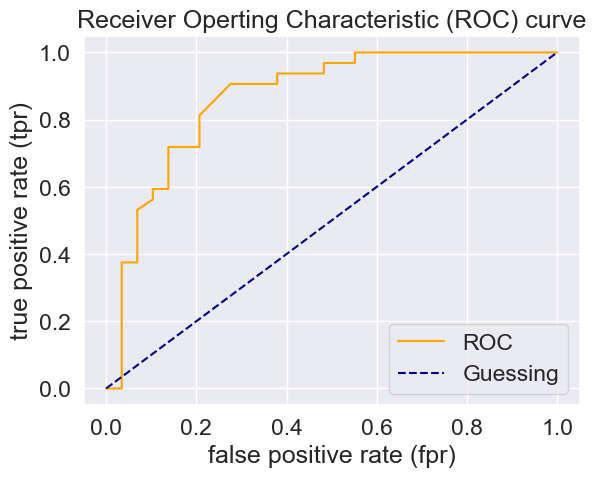

In [33]:
# Create a function for plotting the ROC curves

import matplotlib.pyplot as plt

def plot_roc_curve(fpr, tpr):
    """
    Plots a Roc curve given the false positive rate(fpr)
    and true postivite rate (tpr) of a model
    """
    # plot roc curve 
    plt.plot(fpr,tpr, color="orange", label="ROC")

    # plot line with no predictive power (baseline)
    plt.plot([0,1],[0,1], color= "darkblue", linestyle = "--", label="Guessing")

   # Customize the plot
    plt.xlabel("false positive rate (fpr)")
    plt.ylabel("true positive rate (tpr)")
    plt.title("Receiver Operting Characteristic (ROC) curve")
    plt.legend()
    plt.show()

plot_roc_curve(fpr,tpr)    

In [34]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test,y_probs_positive)

0.8669181034482759

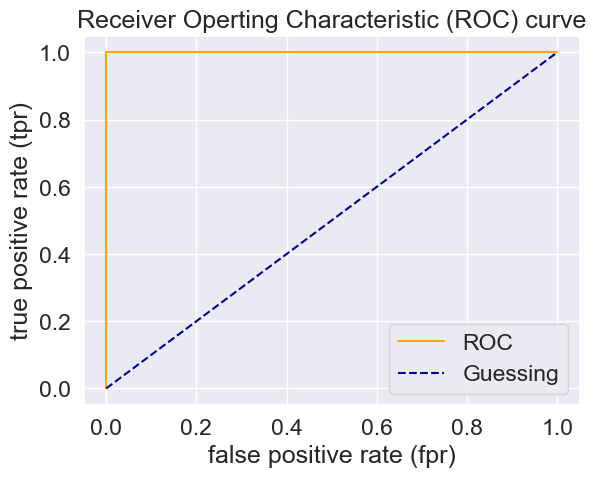

In [35]:
# plot the perfect Roc curve and AUC score
fpr,tpr,thresholds = roc_curve(y_test,y_test)
plot_roc_curve(fpr,tpr)

In [76]:
# perfect auc score 
roc_auc_score(y_test,y_test)

1.0

## confusion metrix
A confusion metrix  is a quick way to campare the labels a model predicts and the actuall lable it wass actuall suoppose to predict 

IN essance , giving you the ide of wher the model is getting confused

In [36]:
from sklearn.metrics import confusion_matrix

y_preds =  clf.predict(x_test)

confusion_matrix(y_test,y_preds)


array([[23,  6],
       [ 6, 26]])

In [37]:
## Visiualize the confusion matrix with pd.crosstable
pd.crosstab(y_test,
            y_preds,
            rownames=["Actual label"],
            colnames=["predicte the lable"]
           )

predicte the lable,0,1
Actual label,,
0,23,6
1,6,26


In [80]:
22+7+8+24

61

In [81]:
len(y_preds)

61

In [38]:
# how to install the conda package directly in the jupyter

import sys 
!conda install --yes --prefix {sys.prefix} seaborn

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.





==> WARNING: A newer version of conda exists. <==
    current version: 25.11.1
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda




<Axes: >

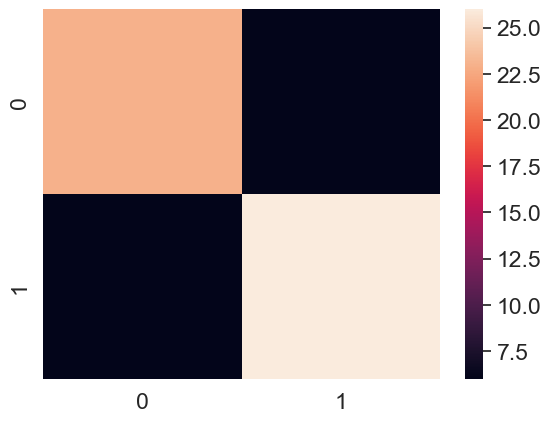

In [40]:
# MAKE our confusion matrix  more cvisal with the seaborn's heatmap()

import seaborn as sns

# set the font scale 
sns.set(font_scale = 1.5)

# craet the confusion matrix

conf_mat = confusion_matrix(y_test,y_preds)

# plot it using the seaborn

sns.heatmap(conf_mat)


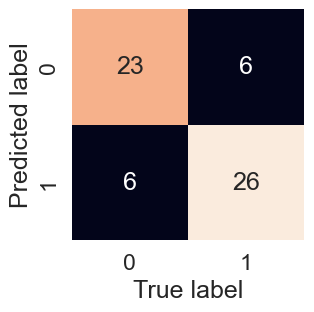

In [43]:
def plot_conf_mat(conf_mat):
    """
    plot a confusion matrix using Seaborn's heatmap()
    """
    fig,ax = plt.subplots(figsize =(3,3))
    ax = sns.heatmap(conf_mat,
                      annot = True, # Annotate the boxes with the conf_mat info 
                    cbar = False)
    plt.xlabel("True label")
    plt.ylabel("Predicted label");

plot_conf_mat(conf_mat)

## classification report 
 ** new topic **

In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.79      0.79      0.79        29
           1       0.81      0.81      0.81        32

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



In [48]:
# where the precision and recall becom valuable 
disease_true = np.zeros(10000)
disease_true[0]= 1   # only one positive case 

disease_preds = np.zeros(10000) # model predicts every case as  0 

pd.DataFrame(classification_report(disease_true,
                                   disease_true,
                                   output_dict= True))

,0.0,1.0,accuracy,macro avg,weighted avg
precision,1.0,1.0,1.0,1.0,1.0
recall,1.0,1.0,1.0,1.0,1.0
f1-score,1.0,1.0,1.0,1.0,1.0
support,9999.0,1.0,1.0,10000.0,10000.0


## 4.2.2 Regression model evaluation metrics 
 1. R^2 (pronouced r-square) pr coefficient of termination
 2. Mean absolute error (MAE)
 3. Mean square error (MSE)

**R^2**

  what r-square does :  campares your model predication to the mean of the target . values 
  can range  from neagtive (a very poor model) to the 1. for example , if all your model does is predict the mean of the 
  targets , it's R^2 value is 0 , and if  your model predict the range of number perfectly it's R^2 value would be 1

In [64]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

x =  housing_df.drop("target", axis = 1)
y = housing_df["target"]

x_train,x_test, y_train,y_test = train_test_split(x,y, test_size = 0.2)

model = RandomForestRegressor()
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [65]:
print(model.score(x_train, y_train))


0.9736861165621588


In [66]:
from sklearn.metrics import r2_score 

# fill an array with y_test mean 

y_test_mean = np.full(len(y_test), y_test.mean())

In [68]:
y_test.mean()

np.float64(2.0550030959302323)

In [69]:
y_test_mean

array([2.0550031, 2.0550031, 2.0550031, ..., 2.0550031, 2.0550031,
       2.0550031], shape=(4128,))

In [70]:
r2_score(y_test, y_test_mean)

0.0

In [72]:
r2_score(y_test,y_test)

1.0

**Mean absolute error (MAE)**

MAE is the average of the absolute difference between the actual values and predictions,
It gives the idea of how much your model's predications are  wrong 

In [74]:
# Mean absolute error 
from sklearn.metrics import mean_absolute_error

y_preds = model.predict(x_test)  # predicted values 
mae = mean_absolute_error(y_test,y_preds)
mae


0.32656738464147306

In [77]:
## visualizing it 
df = pd.DataFrame(data={"actual values": y_test,
                       "predicted values": y_preds})
df["difference"] = df["predicted values"]-df["actual values"]
df

,actual values,predicted values,difference
20046,0.47700,0.493900,0.016900
3024,0.45800,0.754940,0.296940
15663,5.00001,4.928596,-0.071414
20484,2.18600,2.540240,0.354240
9814,2.78000,2.331760,-0.448240
...,...,...,...
15362,2.63300,2.219830,-0.413170
16623,2.66800,1.947760,-0.720240
18086,5.00001,4.836378,-0.163632
2144,0.72300,0.717820,-0.005180


**mean square error**

In [79]:
# mean square error 
from sklearn.metrics import mean_squared_error

y_preds = model.predict(x_test)
mse = mean_squared_error(y_test,y_preds)
mse


0.25336408094921037

In [80]:
# caluclating the mse  by our own without impoting it
square = np.square(df["difference"])
square

20046    0.000286
3024     0.088173
15663    0.005100
20484    0.125486
9814     0.200919
           ...   
15362    0.170709
16623    0.518746
18086    0.026775
2144     0.000027
3665     0.026507
Name: difference, Length: 4128, dtype: float64

In [81]:
square.mean()

np.float64(0.25336408094921037)

In [82]:
0.32656738464147306-0.25336408094921037

0.07320330369226269

In [83]:
0.25336408094921037-0.32656738464147306

-0.07320330369226269

### 4.2.3 finnaly uing the `scoring` parameter

In [84]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
np.random.seed(42)
x = heart_disease.drop("target", axis = 1)
y = heart_disease["target"]

clf = RandomForestClassifier()



In [88]:
np.random.seed(42)
cv_acc = cross_val_score(clf,x,y,cv=5, scoring= None)
cv_acc

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

In [87]:
# cross-validated accuracy 
print(f"the cross-validated accuracy is ; {np.mean(cv_acc)*100:.2f}%")

the cross-validated accuracy is ; 82.48%


In [90]:
np.random.seed(42)
cv_acc = cross_val_score(clf,x,y,cv=5, scoring="accuracy")
print(f"the cross-validated accuracy is ; {np.mean(cv_acc)*100:.2f}%")

the cross-validated accuracy is ; 82.48%


In [ ]:
# precison
cv_precision = cross_val_score(clf, x,y, cv = 5, scoring="precision")
np.mean(cv_precision)

In [94]:
# Recall
cv_recall = cross_val_score(clf,x,y,cv=5,scoring="recall")
np.mean(cv_recall)

np.float64(0.8727272727272727)

In [95]:
cv_f1 = cross_val_score(clf,x,y,cv=5,scoring="f1")
np.mean(cv_f1)

np.float64(0.8256946143361409)

## how about our regreesion model 

In [97]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

x= housing_df.drop("target",axis=1)
y = housing_df["target"]

model = RandomForestRegressor()


In [109]:
np.random.seed(42)
cv_r2 = cross_val_score(model,x,y,cv=5,scoring=None)
np.mean(cv_r2)

np.float64(0.6521550148270838)

In [107]:
np.random.seed(42)
cv_r2 = cross_val_score(model,x,y,cv=5,scoring="r2")
np.mean(cv_r2)

np.float64(0.6521550148270838)

In [108]:
# mean absolute error
cv_mae = cross_val_score(model, x, y, scoring="neg_mean_absolute_error")
cv_mae

array([-0.53907598, -0.41186259, -0.43893047, -0.464205  , -0.47454934])

In [111]:
# mean sqaure error
cv_mse =  cross_val_score(model,x,y,cv=5, scoring="neg_mean_squared_error")
cv_mse

array([-0.51328085, -0.35070703, -0.37304367, -0.44907837, -0.46924468])

In [112]:
np.mean(cv_mse)

np.float64(-0.4310709217335053)

### 4.3 using different evalution matrics as scikit-learn function

 **classification evaluating functions**

In [115]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

np.random.seed(42)
x = heart_disease.drop("target",axis=1)
y = heart_disease["target"]

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2)

clf = RandomForestClassifier()

clf.fit(x_train,y_train)

# make some predications 
y_preds = clf.predict(x_test)

# Evalute the classifier 
print("Classifier metrics on the test set")
print(f"Accuracy: {accuracy_score(y_test,y_preds)*100:.2f}%")
print(f"precision:{precision_score(y_test,y_preds)*100:.2f}%")
print(f"Recall:{recall_score(y_test, y_preds)*100:.2f}%")
print(f"F1:{f1_score(y_test,y_preds)*100:.2f}%")


Classifier metrics on the test set
Accuracy: 85.25%
precision:84.85%
Recall:87.50%
F1:86.15%


**Regression evaluation fuctions**

In [117]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

x = heart_disease.drop("target",axis = 1)
y = heart_disease["target"]
x_train,x_test, y_train,y_test = train_test_split(x,y,test_size=0.2)

model = RandomForestRegressor()
model.fit(x_train,y_train)

# make the predication using the regression functions 
y_preds = model.predict(x_test)

# Evaluting the regressior model

print("Regression model metrices on the test set")
print(f"R^2:{r2_score(y_test,y_preds)*100:.2f}%")
print(f"meanAbsoluteError(MAE): {mean_absolute_error(y_test,y_preds)*100:.2f}%")
print(f"meanSqureError(MsE): {mean_squared_error(y_test,y_preds)*100:.2f}%")



Regression model metrices on the test set
R^2:26.91%
meanAbsoluteError(MAE): 30.59%
meanSqureError(MsE): 18.27%


### improving the model

First predictions = baseline predications 
First model = baseline model

from the data prespective: 
* could we collect the more data ! (generally, the more data , the better)
* could we improve the data !

from the model prespective :
* Is their any better model that can we use !
* could we improve the current model !

parameters = model find these patterns in data 
hyperparameters = settings on the model you can adjust to (potenially improve its ability to find pattern)

Three ways to adust the hyper parameters:

* by hand 
* Randomly with the RandomSearchCV
* Exhaustively with GridSearchCV



In [122]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()



In [123]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

 ### 5.1 Tuning hyperparametrs by hand 
let's make the 3 sets, trining , validation and test sets 

In [125]:
# base line parameters 
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

 ## we are going to try and adjut: 
* `max_depth`
* `max_features`
* `min_samples_leaf`
* `min_sample_split`
* `n_estimators`

In [137]:
def evalute_preds(y_true, y_preds):
    """
    perfome the evalution camparison on y_true lable vs y_preds labels.
    on a classification 
    """
    accuracy = accuracy_score(y_true, y_preds)
    precision = precision_score(y_true, y_preds)
    recall = recall_score(y_true,y_preds)
    f1 = f1_score(y_true, y_preds)
    metric_dict = {"accuracy": round(accuracy,2),
                  "precision":round(precision,2),
                  "recall":round(recall, 2),
                  "f1":round(f1,2)}
    print(f"Acc: {accuracy*100:.2f}%")
    print(f"Precison:{precision:.2f}")
    print(f"recall:{recall:.2f}")
    print(f"f1:{f1:.2f}")

    return metric_dict

In [138]:
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42) # here manuly creting the functinonality of the train_test_split

# shufffel the data 
heart_disease_shuffled = heart_disease.sample(frac = 1)

#split x , y 
x = heart_disease_shuffled.drop("target", axis = 1)
y = heart_disease_shuffled["target"]

# split the data into train, validation and test sets 


train_split = round(0.7 * len(heart_disease_shuffled)) # 70 % of data
valid_split = round(train_split + 0.15 * len(heart_disease_shuffled)) # 15 % of data
x_train, y_train  = x[:train_split], y[:train_split]
x_valid,y_valid = x[train_split:valid_split], y[train_split:valid_split]
x_test,y_test = x[valid_split:],y[valid_split:]

clf = RandomForestClassifier()
clf.fit(x_train,y_train)


# make baseline  predictions 
y_preds= clf.predict(x_valid)

# make the cclassifier on validation set
baseline_metrics = evalute_preds(y_valid,y_preds)
baseline_metrics
                    

Acc: 82.22%
Precison:0.81
recall:0.88
f1:0.85


{'accuracy': 0.82, 'precision': 0.81, 'recall': 0.88, 'f1': 0.85}

In [132]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [139]:
clf2 = RandomForestClassifier(max_depth = 10) 
## in shot doing by hand take too mush time and code 


### 5.2  Hyper parameters tuning with the RandomizedSearchCV 


In [144]:
from sklearn.model_selection import RandomizedSearchCV

# making the dictionarory of the hyperparametrers that we want to adust 

grid = {"n_estimators":[10,100,200,500,1000,1200], # the values here [10,100 ...] is not random it is reserched by using doc
       "max_depth":[None,5,10,20,30],
       "max_features":["auto","sqrt"],
       "min_samples_split":[2,4,6],
       "min_samples_leaf":[1,2,3]}

np.random.seed(42)

# split x and y 

x = heart_disease_shuffled.drop("target", axis = 1)
y = heart_disease_shuffled["target"]

# split into the train and test set

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2)

# Instantiate  RandomForestClassifier
clf = RandomForestClassifier(n_jobs =1)

# setup  RandomizedSerachCV 

rs_clf = RandomizedSearchCV(estimator= clf,
                           param_distributions = grid,
                           n_iter = 10,# Number of models to try 
                           cv= 5,
                           verbose = 2)  


#fit the  RandomizedSerchCV version of clf 

rs_clf.fit(x_train,y_train);

    

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   2.6s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   2.5s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   2.5s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   2.5s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   2.5s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=30, max_features=auto, min_samples_leaf=2, min_samples_split=4, n_estimators=100

C:\Users\Ashavdeep\Desktop\sample_project_1\env\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Ashavdeep\Desktop\sample_project_1\env\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Ashavdeep\Desktop\sample_project_1\env\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
  File "C:\Users\Ashavdeep\Desktop\sample_project_1\env\Lib\site-packages\sklearn\base.py", line 492, in _validate_pa

In [145]:
rs_clf.best_params_

{'n_estimators': 200,
 'min_samples_split': 6,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': None}

In [147]:
# make the predictions with the best hyperparameters

rs_y_preds =  rs_clf.predict(x_test)

# evalutae the predications 
s_metrics = evalute_preds(y_test, rs_y_preds)

Acc: 81.97%
Precison:0.77
recall:0.86
f1:0.81
